# Impact functions

In this notebook we read Entity files for El Salvador and plot (uncalibrated) Impact Functions for maize, beans and sorghum.

## Impact functions from the Entity file

Impact functions describe the relationship between the intensity of a hazard and its effect on your chosen exposure.

They are stored in the Entity Excel workbook in the 'impact_functions' sheet. The sheet can specify any number of impact functions. Each function is read in and stored in an `ImpactFunc` object, which are then grouped into an `ImpactFuncSet` object and stored in the `Entity`'s `impact_funcs` attribute.

All of these classes are part of CLIMADA's `climada.entity` package.

There are two ways to create impact functions for an analysis: from an Entity file, or programatically by constructing an `ImpactFunc` object. This notebook reads from a file. For more information on Impact Functions, see the [CLIMADA User Guide](https://climada-python.readthedocs.io/en/stable/user-guide/climada_entity_ImpactFuncSet.html).

Let's read in the Entity files and visualize the functions:

In [1]:
from pathlib import Path

# Set the directory where our Entity files are located
ENTITY_DIR = "../data/entity_files_uncalibrated/"
# Give a dictionary of Entity file names
ENTITY_FILES = {
    "maize": "El_Salvador_Entity_Drought_Maize.xlsx",
    "beans": "El_Salvador_Entity_Drought_Beans.xlsx",
    "sorghum": "El_Salvador_Entity_Drought_Sorghum.xlsx"
}
entity_filepaths = {crop: Path(ENTITY_DIR) / filename for crop, filename in ENTITY_FILES.items()}

In [2]:
import copy
from climada.entity import Entity

# Read the Entity file and set additional metadata for the Exposures
entity_dict = {}
for crop, filepath in entity_filepaths.items():
    print(f"Reading {filepath.name}...")
    entity = Entity.from_excel(filepath)
    entity.exposures.ref_year = 2026
    entity.exposures.value_unit = "kg"
    entity.exposures.description = f"Annual {crop} production ({entity.exposures.value_unit})"
    entity_dict[crop] = copy.deepcopy(entity)


Reading El_Salvador_Entity_Drought_Maize.xlsx...
Reading El_Salvador_Entity_Drought_Beans.xlsx...
Reading El_Salvador_Entity_Drought_Sorghum.xlsx...


In [3]:
HAZ_TYPE = "DR"  # This is the code we use to indicate impact functions for drought in Impact Functions

# We can then store the impact function sets in their own dict:
impf_set_dict = {crop: entity.impact_funcs for crop, entity in entity_dict.items()}

for crop, impf_set in impf_set_dict.items():
    print(f"There are {impf_set.size()} impact functions for {crop} with ID(s) {impf_set.get_ids(haz_type=HAZ_TYPE)}.")

There are 1 impact functions for maize with ID(s) [101].
There are 1 impact functions for beans with ID(s) [102].
There are 1 impact functions for sorghum with ID(s) [103].


Drought impact functions based on SPEI indices look different from most other impact functions in CLIMADA, because the size of impacts decrease as the intensity of the hazard _decreases_.

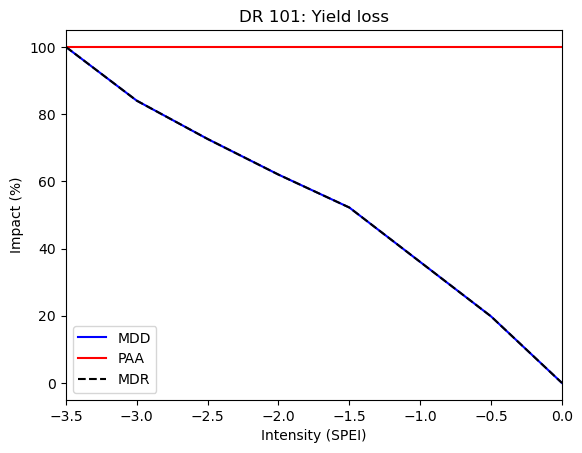

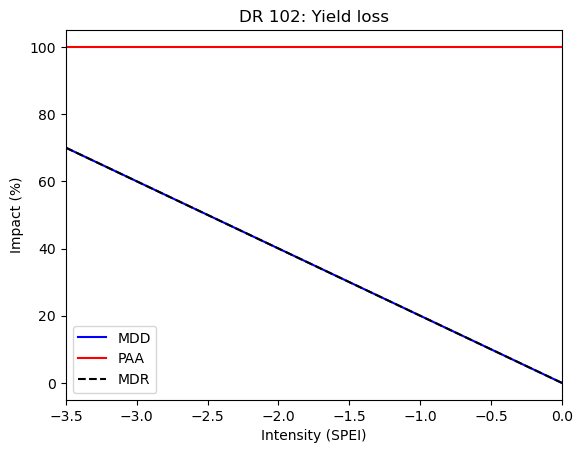

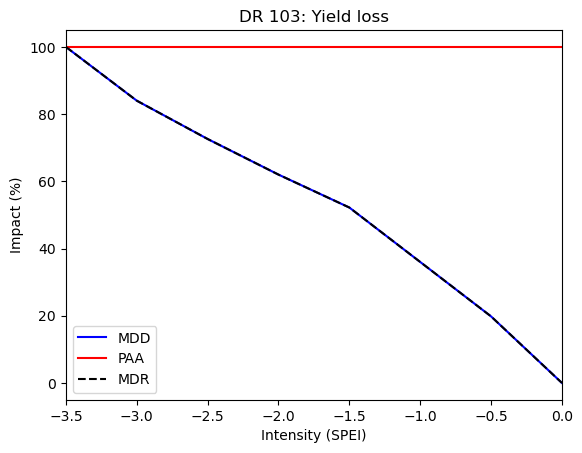

In [4]:
# Visualize the impact functions
for impf_set in impf_set_dict.values():
    impf_set.plot(fun_id=None)  # Specify fun_id to plot a single function when you have several

An impact function is defined by the following properties:

In [5]:
# Choose an example impact function to examine in more detail
example_impf_set = impf_set_dict["maize"]
example_fun_ids = example_impf_set.get_ids(haz_type=HAZ_TYPE)
example_impf = example_impf_set.get_func(haz_type=HAZ_TYPE,fun_id=example_fun_ids[0])

print(f"Details from an example impact function:")
# The function ID
print(f"Function ID: {example_impf.id}")
# The hazard type ('None' is acceptable)
print(f"Hazard type: {example_impf.haz_type}")
# The intensity unit
print(f"Intensity unit: {example_impf.intensity_unit}")
# The intensity values for which damage is defined
print(f"Intensity values: {example_impf.intensity}")
# The mean damage degree values: the average damage experienced by assets at these hazard intensities
print(f"Mean damage degree values: {example_impf.mdd}")
# The percentage of assets affected: the average percentage of assets affected by this intensity of hazard at a single location
print(f"Percentage of assets affected: {example_impf.paa}")
# The name (optionally)
print(f"Name: {example_impf.name}")

Details from an example impact function:
Function ID: 101
Hazard type: DR
Intensity unit: SPEI
Intensity values: [-3.5 -3.  -2.5 -2.  -1.5 -1.  -0.5  0. ]
Mean damage degree values: [1.    0.84  0.726 0.62  0.522 0.36  0.198 0.   ]
Percentage of assets affected: [1 1 1 1 1 1 1 1]
Name: Yield loss
